# Ground Water Contamination

## 1. The model — two PDEs from Monday's conservation law

An aquifer is a porous medium (sand, gravel) whose pores are filled with water. Two unknowns:

| quantity | symbol | unit |
|---|---|---|
| hydraulic head (water pressure expressed as a height) | $h(x)$ | m |
| contaminant concentration in the pore water | $c(x,t)$ | kg/m³ (or relative to the source, $c/c_0$) |

**Darcy's law (1856)** — water flows from high head to low head, proportional to the gradient:

$$q = -K\,\nabla h \qquad q = \text{Darcy flux [m/day]},\quad K = \text{hydraulic conductivity [m/day]}$$

($K \approx 10$ m/day for sand, $0.1$ for silt, $10^{-4}$ for clay — it jumps by orders of magnitude between layers, exactly the "discontinuous coefficient" situation from the PDE lecture.)

**Conservation of water** (steady, incompressible — Monday's $\partial_t\rho + \nabla\cdot(\rho v) = f$ with $\rho$ constant):

$$\nabla\cdot q = f \quad\Longrightarrow\quad \boxed{\,-\nabla\cdot\big(K\,\nabla h\big) = f\,}$$

The **Poisson equation** again — same as gravity and steady heat conduction. $f$ = wells (extraction $<0$, injection $>0$), recharge from rain. Boundary conditions: prescribed head (river, lake) or no-flow (bedrock).

The water moves through the pores at the **pore velocity** $v = q/\phi$ ($\phi$ = porosity ≈ 0.3), which is what carries the contaminant.

**Conservation of contaminant** — Monday's "conservation of concentration of a substance", with the same two fluxes as the heat equation:

$$\boxed{\,\phi\,\partial_t c + \nabla\cdot\big(\underbrace{q\,c}_{\text{advection}} - \underbrace{\phi D\,\nabla c}_{\text{dispersion}}\big) = r\,}$$

- advection: the plume is carried with the water,
- dispersion: spreading by molecular diffusion + the tortuous pore paths ($D \approx \alpha_L |v|$, $\alpha_L$ = dispersivity, metres),
- $r$: sources (the leak), sinks (wells remove solute with the water), reactions (decay, sorption).

**The pattern:** solve the *elliptic* head equation once → get the velocity field → solve the *parabolic* transport equation in time. Below, both with the finite-volume / Euler tools of this week.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import erfc
import scipy.sparse as sp
import scipy.sparse.linalg as spla

BLUES = LinearSegmentedColormap.from_list("seq-blue", ["#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


## 2. One-dimensional soil column — verification

A column of length $L$, water flowing at constant $v$, contaminated water ($c = c_0$) entering at $x = 0$ from $t = 0$. The transport equation reduces to

$$\partial_t c + v\,\partial_x c = D\,\partial_{xx} c, \qquad c(0,t) = c_0,\quad c(x,0) = 0,$$

which has the exact **Ogata–Banks** solution

$$c(x,t) = \frac{c_0}{2}\left[\operatorname{erfc}\frac{x - vt}{2\sqrt{Dt}} + e^{vx/D}\operatorname{erfc}\frac{x + vt}{2\sqrt{Dt}}\right].$$

Numerics: cells of width $\Delta x$, **upwind** for the advective flux (take the concentration from the side the water comes from), central differences for dispersion, **forward Euler** in time. Stability requires

$$\Delta t\left(\frac{v}{\Delta x} + \frac{2D}{\Delta x^2}\right) \le 1$$

— the PDE version of the $h\alpha < 2$ limit you saw for the logistic equation.


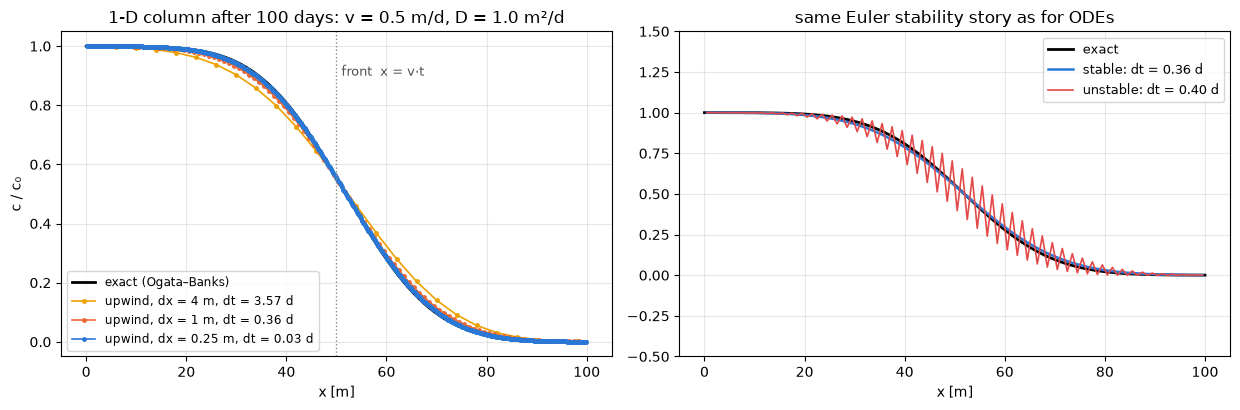

In [2]:
# PART 1 — 1-D soil column: advection–dispersion, explicit Euler in time, upwind in space
#          verified against the exact Ogata–Banks solution
# =============================================================================
L, v, D, c0 = 100.0, 0.5, 1.0, 1.0            # m, m/day, m²/day, concentration at inlet
T = 100.0                                     # days

def ogata_banks(x, t):
    return c0 / 2 * (erfc((x - v * t) / (2 * np.sqrt(D * t))) + np.exp(v * x / D) * erfc((x + v * t) / (2 * np.sqrt(D * t))))

def column(nx, cfl):
    dx = L / nx
    x = (np.arange(nx) + 0.5) * dx
    dt = cfl / (v / dx + 2 * D / dx**2)                       # stability: dt*(v/dx + 2D/dx²) <= 1
    nsteps = int(np.ceil(T / dt)); dt = T / nsteps
    c = np.zeros(nx)
    for n in range(nsteps):
        cw = np.concatenate([[c0], c[:-1]])                   # upwind: value on the west face comes from the left
        ce = np.concatenate([c[1:], [c[-1]]])                 # outflow: zero gradient
        adv = v * (c - cw) / dx
        dif = D * (ce - 2 * c + cw) / dx**2
        c = c + dt * (-adv + dif)                             # forward Euler
    return x, c, dt, nsteps

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
xx = np.linspace(0, L, 400)
ax[0].plot(xx, ogata_banks(xx, T), "k-", lw=2, label="exact (Ogata–Banks)")
for nx, col in [(25, "#eda100"), (100, "#eb6834"), (400, "#2a78d6")]:
    x, c, dt, ns = column(nx, cfl=0.9)
    ax[0].plot(x, c, "o-", color=col, ms=2.5, lw=1.2, label=f"upwind, dx = {L/nx:g} m, dt = {dt:.2f} d")
ax[0].axvline(v * T, color="#8a8984", ls=":", lw=1); ax[0].text(v * T + 1, 0.9, "front  x = v·t", color="#52514e", fontsize=9)
ax[0].set_xlabel("x [m]"); ax[0].set_ylabel("c / c₀"); ax[0].set_title(f"1-D column after {T:.0f} days: v = {v} m/d, D = {D} m²/d")
ax[0].legend(fontsize=8.5); ax[0].grid(alpha=0.3)

x, c_ok, dt_ok, _ = column(100, cfl=0.9)
x, c_bad, dt_bad, _ = column(100, cfl=1.01)
ax[1].plot(xx, ogata_banks(xx, T), "k-", lw=2, label="exact")
ax[1].plot(x, c_ok, color="#2a78d6", lw=1.8, label=f"stable: dt = {dt_ok:.2f} d")
ax[1].plot(x, c_bad, color="#e34948", lw=1.2, label=f"unstable: dt = {dt_bad:.2f} d")
ax[1].set_ylim(-0.5, 1.5); ax[1].set_xlabel("x [m]"); ax[1].set_title("same Euler stability story as for ODEs")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [3]:
for nx in [25, 100, 400]:
    x, c, dt, ns = column(nx, 0.9)
    print(f"nx={nx:4d}  dx={L/nx:5.2f} m  dt={dt:5.3f} d  steps={ns:5d}  max|c - exact| = {np.abs(c - ogata_banks(x, T)).max():.3f}")


nx=  25  dx= 4.00 m  dt=3.571 d  steps=   28  max|c - exact| = 0.050
nx= 100  dx= 1.00 m  dt=0.360 d  steps=  278  max|c - exact| = 0.022
nx= 400  dx= 0.25 m  dt=0.026 d  steps= 3778  max|c - exact| = 0.007


**What to see**

- The scheme converges to the exact solution as $\Delta x \to 0$ (max error 0.05 → 0.02 → 0.007), but slowly — first order, like Euler.
- On the coarse grid the numerical front is *smoother* than the exact one: upwind adds **numerical diffusion** $\approx v\Delta x/2$ on top of the physical $D$. With $\Delta x = 4$ m that's $1$ m²/day — as large as $D$ itself. Refine the grid or use a higher-order scheme when the real dispersion is small.
- Break the time-step condition by 1 % and the solution develops growing checkerboard oscillations — the same mechanism as Euler on $u' = -\lambda u$ with $h\lambda > 2$.


## 3. Two-dimensional aquifer — a leaking tank, a clay lens and a drinking-water well

Plan view of a $200 \times 100$ m aquifer, uniform thickness:

- regional flow from left ($h = 12$ m) to right ($h = 10$ m); no-flow boundaries top and bottom,
- sand $K = 10$ m/day with a **clay lens** ($K = 0.1$) in the middle,
- a **pumping well** at $(150, 50)$,
- a **tank** at $(20$–$30,\ 45$–$55)$ that leaks for 200 days, keeping the soil beneath it at $c = c_0$, then is repaired.

Step 1: solve $-\nabla\cdot(K\nabla h) = f$ with finite volumes (harmonic mean of $K$ across cell faces — the right average for fluxes through layers in series), sparse direct solver.
Step 2: Darcy fluxes on the cell faces, then explicit upwind transport as in 1-D.


In [4]:
# PART 2 — 2-D aquifer: steady Darcy flow (Poisson for the head) + contaminant plume
# =============================================================================
Lx, Ly = 200.0, 100.0                          # m
nx, ny = 100, 50                               # cells  -> dx = dy = 2 m
dx, dy = Lx / nx, Ly / ny
xc, yc = (np.arange(nx) + 0.5) * dx, (np.arange(ny) + 0.5) * dy
X, Y = np.meshgrid(xc, yc)                     # arrays are [j, i] = [y, x]

phi   = 0.3                                    # porosity
K     = np.full((ny, nx), 10.0)                # hydraulic conductivity [m/day]  (sand)
lens  = (X > 80) & (X < 120) & (Y > 35) & (Y < 65)
K[lens] = 0.1                                  # clay lens: 100x less permeable
h_in, h_out = 12.0, 10.0                       # head at x = 0 and x = Lx  -> gradient 0.01
well_xy, Q_well = (150.0, 50.0), 3.0           # pumping well position, extraction [m²/day per m thickness]
tank = (X > 20) & (X < 30) & (Y > 45) & (Y < 55)   # leaking tank footprint
t_leak = 200.0                                 # leak lasts 200 days, then stops
D = 0.3                                        # dispersion coefficient [m²/day]

# ---- steady head:  -div(K grad h) = f  (finite volumes, harmonic K on faces) ----
idx = lambda j, i: j * nx + i
Kx = 2 * K[:, :-1] * K[:, 1:] / (K[:, :-1] + K[:, 1:])      # faces between (i, i+1)
Ky = 2 * K[:-1, :] * K[1:, :] / (K[:-1, :] + K[1:, :])      # faces between (j, j+1)
rows, cols, vals, b = [], [], [], np.zeros(nx * ny)
def add(r, c, v): rows.append(r); cols.append(c); vals.append(v)
for j in range(ny):
    for i in range(nx):
        k = idx(j, i); diag = 0.0
        if i > 0:      t = Kx[j, i-1] * dy / dx; add(k, idx(j, i-1), -t); diag += t
        if i < nx - 1: t = Kx[j, i]   * dy / dx; add(k, idx(j, i+1), -t); diag += t
        if j > 0:      t = Ky[j-1, i] * dx / dy; add(k, idx(j-1, i), -t); diag += t
        if j < ny - 1: t = Ky[j, i]   * dx / dy; add(k, idx(j+1, i), -t); diag += t
        if i == 0:      t = K[j, i] * dy / (dx / 2); diag += t; b[k] += t * h_in      # Dirichlet at x = 0
        if i == nx - 1: t = K[j, i] * dy / (dx / 2); diag += t; b[k] += t * h_out     # Dirichlet at x = Lx
        add(k, k, diag)
jw, iw = int(well_xy[1] / dy), int(well_xy[0] / dx)
b[idx(jw, iw)] -= Q_well                                       # extraction = negative source
A = sp.csr_matrix((vals, (rows, cols)), shape=(nx * ny, nx * ny))
h = spla.spsolve(A, b).reshape(ny, nx)

# ---- Darcy flux on faces, pore velocity in cells ----
qx_f = -Kx * (h[:, 1:] - h[:, :-1]) / dx                       # (ny, nx-1)
qy_f = -Ky * (h[1:, :] - h[:-1, :]) / dy                       # (ny-1, nx)
qx_in  = -K[:, 0]  * (h[:, 0] - h_in)   / (dx / 2)             # inflow boundary faces
qx_out = -K[:, -1] * (h_out - h[:, -1]) / (dx / 2)
qx_all = np.hstack([qx_in[:, None], qx_f, qx_out[:, None]])    # (ny, nx+1)  west..east faces
qy_all = np.vstack([np.zeros((1, nx)), qy_f, np.zeros((1, nx))])  # no-flow top/bottom  (ny+1, nx)
vx = 0.5 * (qx_all[:, :-1] + qx_all[:, 1:]) / phi              # cell-centred pore velocity for plotting
vy = 0.5 * (qy_all[:-1, :] + qy_all[1:, :]) / phi
print(f"\nhead solved: {h.min():.2f} – {h.max():.2f} m;  pore velocity: mean {np.hypot(vx, vy).mean():.3f}, max {np.hypot(vx, vy).max():.3f} m/day")



head solved: 10.01 – 11.99 m;  pore velocity: mean 0.302, max 1.146 m/day


In [5]:
# ---- transport: phi dc/dt + div(q c) - div(phi D grad c) = 0, explicit Euler + upwind ----
ux, uy = qx_all / phi, qy_all / phi                            # pore velocities on faces
dt = 0.9 / (np.abs(ux).max() / dx + np.abs(uy).max() / dy + 2 * D / dx**2 + 2 * D / dy**2)
print(f"transport time step dt = {dt:.3f} days (CFL + diffusion limit)")

def step(c):
    cw = np.hstack([np.zeros((ny, 1)), c])                     # west-face upwind candidates (inflow c = 0)
    ce = np.hstack([c, c[:, -1:]])                             # east (outflow: zero gradient)
    c_face_x = np.where(ux > 0, cw, ce)                        # upwind value on every x-face
    Fx = ux * c_face_x                                         # advective flux on x-faces
    cs = np.vstack([c[:1, :], c]); cn = np.vstack([c, c[-1:, :]])
    c_face_y = np.where(uy > 0, cs, cn)
    Fy = uy * c_face_y
    adv = (Fx[:, 1:] - Fx[:, :-1]) / dx + (Fy[1:, :] - Fy[:-1, :]) / dy
    cp = np.pad(c, 1, mode="edge")                             # zero-flux ghost cells for diffusion
    dif = D * ((cp[1:-1, 2:] - 2 * c + cp[1:-1, :-2]) / dx**2 + (cp[2:, 1:-1] - 2 * c + cp[:-2, 1:-1]) / dy**2)
    sink = np.zeros_like(c); sink[jw, iw] = Q_well * c[jw, iw] / (phi * dx * dy)   # the well removes solute with the water
    return c + dt * (-adv + dif - sink)

c = np.zeros((ny, nx))
t, snapshots, times = 0.0, {}, [150, 350, 550, 900]
well_series = []
while t < times[-1] + 1e-9:
    if t < t_leak: c[tank] = 1.0                               # tank keeps the soil beneath it saturated
    c = step(c); t += dt
    well_series.append((t, c[jw, iw]))
    for T_ in times:
        if T_ not in snapshots and t >= T_: snapshots[T_] = c.copy()
well_series = np.array(well_series)


transport time step dt = 0.539 days (CFL + diffusion limit)


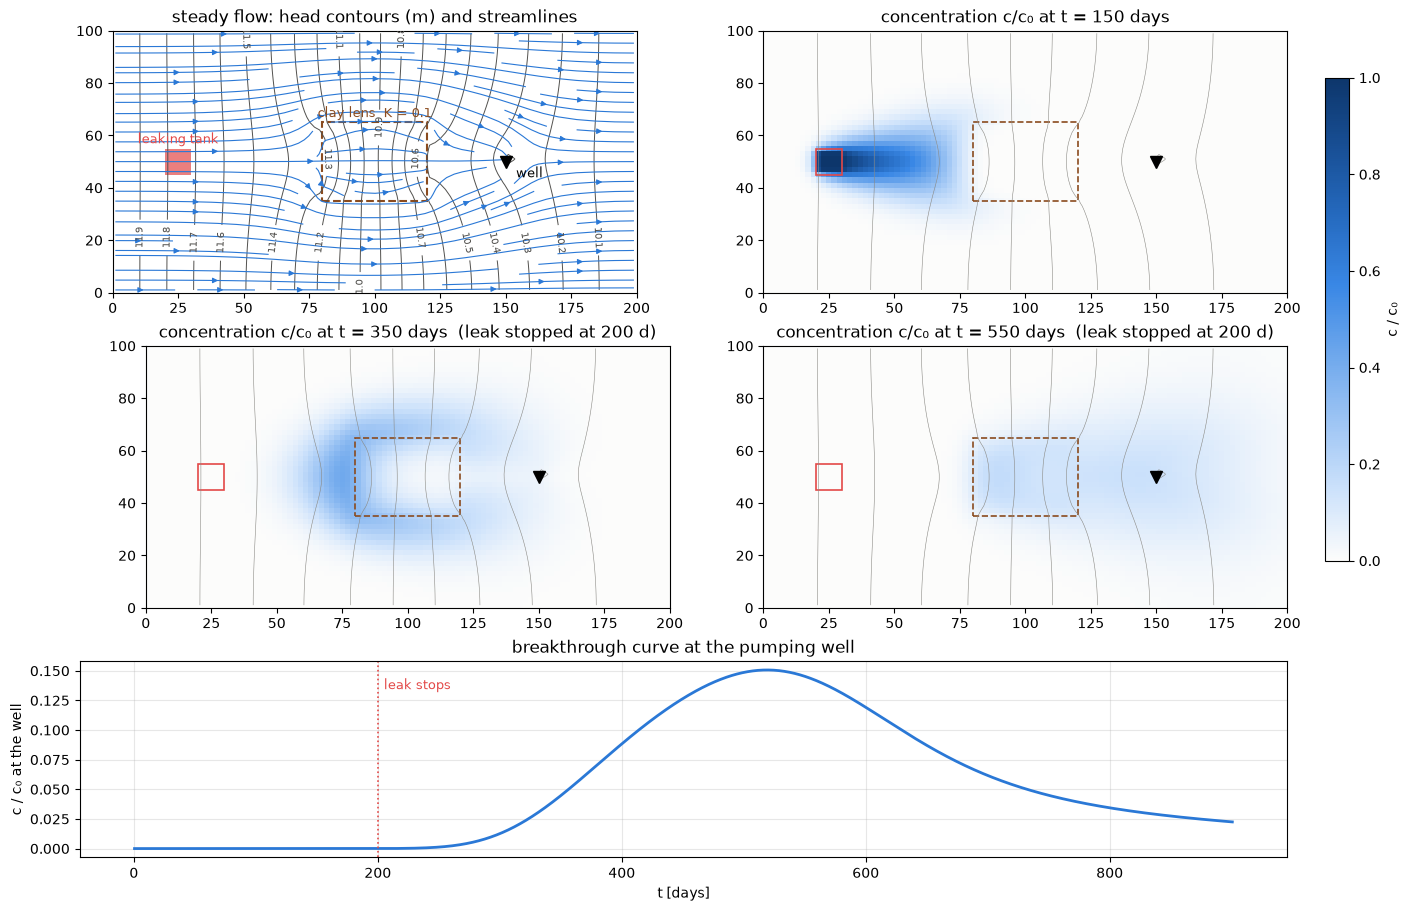

contaminant reaches the well (c > 1 % of c₀) after 294 days;  peak 0.15 c₀ at t = 519 days


In [6]:
# ---- figure: flow field + plume snapshots + breakthrough at the well ----
fig = plt.figure(figsize=(14, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.75])
ax0 = fig.add_subplot(gs[0, 0])
cs_ = ax0.contour(X, Y, h, levels=np.linspace(h_out, h_in, 21), colors="#52514e", linewidths=0.7)
ax0.clabel(cs_, fmt="%.1f", fontsize=7, colors="#52514e")
ax0.streamplot(xc, yc, vx, vy, color="#2a78d6", density=0.9, linewidth=0.8, arrowsize=0.8)
ax0.add_patch(plt.Rectangle((80, 35), 40, 30, fill=False, ec="#8a4b1f", lw=1.5, ls="--")); ax0.text(100, 67, "clay lens  K = 0.1", ha="center", color="#8a4b1f", fontsize=9)
ax0.add_patch(plt.Rectangle((20, 45), 10, 10, fc="#e34948", alpha=0.7)); ax0.text(25, 57, "leaking tank", ha="center", color="#e34948", fontsize=9)
ax0.plot(*well_xy, "v", color="k", ms=9); ax0.text(well_xy[0] + 4, well_xy[1] - 6, "well", fontsize=9)
ax0.set_title("steady flow: head contours (m) and streamlines"); ax0.set_aspect("equal"); ax0.set_xlim(0, Lx); ax0.set_ylim(0, Ly)

axes = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
for ax, T_ in zip(axes, times[:3]):
    im = ax.pcolormesh(np.arange(nx + 1) * dx, np.arange(ny + 1) * dy, snapshots[T_], cmap=BLUES, vmin=0, vmax=1, shading="flat")
    ax.contour(X, Y, h, levels=np.linspace(h_out, h_in, 11), colors="#8a8984", linewidths=0.4)
    ax.add_patch(plt.Rectangle((80, 35), 40, 30, fill=False, ec="#8a4b1f", lw=1.2, ls="--"))
    ax.add_patch(plt.Rectangle((20, 45), 10, 10, fill=False, ec="#e34948", lw=1.2))
    ax.plot(*well_xy, "v", color="k", ms=8)
    ax.set_title(f"concentration c/c₀ at t = {T_} days" + ("  (leak stopped at 200 d)" if T_ > t_leak else ""))
    ax.set_aspect("equal"); ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="c / c₀")

ax3 = fig.add_subplot(gs[2, :])
ax3.plot(well_series[:, 0], well_series[:, 1], color="#2a78d6", lw=2)
ax3.axvline(t_leak, color="#e34948", ls=":", lw=1.2); ax3.text(t_leak + 5, ax3.get_ylim()[1] * 0.85 if well_series[:, 1].max() > 0 else 0.01, "leak stops", color="#e34948", fontsize=9)
ax3.set_xlabel("t [days]"); ax3.set_ylabel("c / c₀ at the well"); ax3.set_title("breakthrough curve at the pumping well"); ax3.grid(alpha=0.3)
plt.show()

i_first = np.argmax(well_series[:, 1] > 0.01)
print(f"contaminant reaches the well (c > 1 % of c₀) after {well_series[i_first, 0]:.0f} days;  peak {well_series[:, 1].max():.2f} c₀ at t = {well_series[np.argmax(well_series[:, 1]), 0]:.0f} days")


## 4. Reading the result

- **Flow field.** Head contours are straight far from the lens and *bend around* it — water takes the path of least resistance, so the streamlines diverge above and below the clay and almost none pass through it. Near the well the contours close in: the well creates a local depression in the head that pulls water from a strip upstream, the **capture zone**.
- **Plume at 150 d** (leak on): a tongue growing downstream of the tank, widened by dispersion.
- **Plume at 350 d** (leak off): the plume has detached — a slug of contaminated water travelling with the flow, splitting into two lobes around the lens, while the lens itself stays almost clean (tiny velocity inside it). Behind the lens the lobes rejoin.
- **Plume at 550 d:** the northern lobe is being drawn into the well. The **breakthrough curve** at the well is the quantity a water utility actually cares about: nothing for ~300 days, then a rise to 15 % of the source concentration at ~520 days, then a slow tail. Long tails like this — and the *long* cleanup times they imply — are the signature of groundwater contamination.
- **Mass budget check:** with the well sink included, $c \le c_0$ everywhere (without it the well cell "collects" solute and $c$ grows without bound — an easy bug to make).

## 5. What is simplified here (and what the real codes add)

| simplification | reality |
|---|---|
| steady flow | seasonal recharge, pumping schedules → transient head equation $S\,\partial_t h - \nabla\cdot(K\nabla h) = f$ |
| 2-D plan view, constant thickness | 3-D layered aquifers; contaminants denser than water sink (DNAPL) |
| scalar $D$ | dispersion tensor: spreading is much stronger along the flow than across it |
| conservative tracer | sorption to soil (retardation factor $R$), biodegradation ($-\lambda c$), chemistry |
| known, blocky $K$ | $K$ varies over orders of magnitude at all scales and is measured at a handful of boreholes → the **inverse problem** (parameter estimation for a PDE — what you did for the logistic model, now with thousands of unknowns) |
| first-order upwind / Euler | higher-order or implicit schemes, adaptive meshes near the well and the plume front — Prof. Bastian's DUNE code does exactly this |

The point of the exercise: **the same three ideas** — conservation law, constitutive law (Darcy / Fourier), Euler-type time stepping — carry from a scalar ODE all the way to a real environmental PDE model.
